  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ba6e6e9d98bb536fa7806014d712cea94b2ad0dd1e9a755165c7eaf9aa0b42df
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Missing values:
 Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64
Missing dates: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
Mean: Ticker
BTC-USD    31625.380466
dtype: float64
Median: Ticker
BTC-USD    29178.679688
dtype: float64
Standard Deviation: Ticker
BTC-USD    17046.636436
dtype: float64


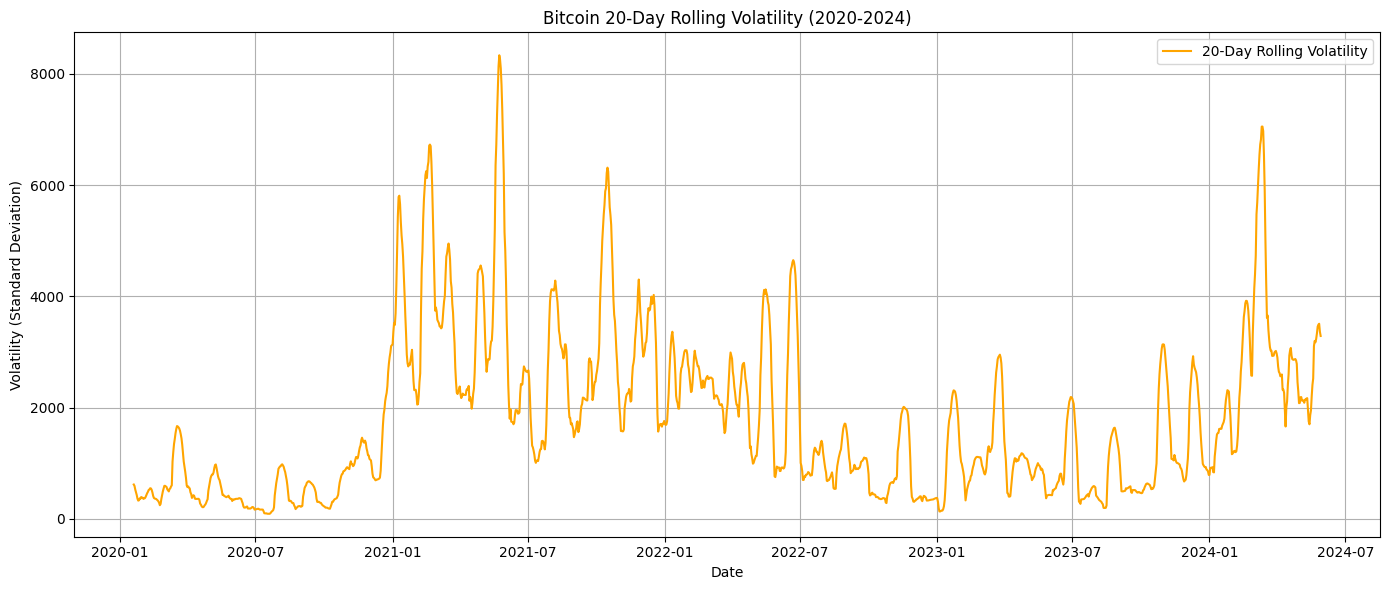

Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2024-05-25  69265.945312  69579.320312  68515.820312  68526.921875   
2024-05-26  68518.093750  69506.226562  68183.890625  69264.289062   
2024-05-27  69394.554688  70597.882812  68232.500000  68512.179688   
2024-05-28  68296.218750  69514.640625  67227.156250  69392.195312   
2024-05-29  67578.093750  68852.460938  67101.492188  68296.351562   

Price            Volume        SMA_20        EMA_20   Volatility  
Ticker          BTC-USD                                           
Date                                                              
2024-05-25  15473071741  65271.129102  66411.180258  3457.125964  
2024-05-26  15628433737  65538.936328  66611.838686  3492.415874  
2024-05-27  25870990717  65891.923242  66876.859258  3508.259557  
2024-05-28  32722265965  66247.337109

In [ ]:
# Install required libraries
!pip install yfinance ta
import yfinance as yf
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt


# Download Bitcoin btc_data
btc_data = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")

# Check missing values
missing = btc_data.isnull().sum()
print("Missing values:\n", missing)

# Check for missing dates
expected_dates = pd.date_range(start=btc_data.index.min(), end=btc_data.index.max(), freq='D')
missing_dates = expected_dates.difference(btc_data.index)
print(f"Missing dates: {len(missing_dates)}")
print(missing_dates)

# Basic Statistics
mean = btc_data['Close'].mean()
median = btc_data['Close'].median()
std_dev = btc_data['Close'].std()

print("Mean:", mean)
print("Median:", median)
print("Standard Deviation:", std_dev)

# Moving Averages
btc_data['SMA_20'] = btc_data['Close'].rolling(window=20).mean()
btc_data['EMA_20'] = btc_data['Close'].ewm(span=20, adjust=False).mean()

# Stochastic Oscillator
def compute_stochastic(btc_data, k_window=14, d_window=3):
    low_min = btc_data['Low'].rolling(window=k_window).min()
    high_max = btc_data['High'].rolling(window=k_window).max()
    k = 100 * ((btc_data['Close'] - low_min) / (high_max - low_min))
    d = k.rolling(window=d_window).mean()
    return k, d


# Volatility (Rolling Std Dev)
btc_data['Volatility'] = btc_data['Close'].rolling(window=20).std()

plt.figure(figsize=(14, 6))
plt.plot(btc_data.index, btc_data['Volatility'], label='20-Day Rolling Volatility', color='orange')
plt.title('Bitcoin 20-Day Rolling Volatility (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Preview updated btc_dataframe
print(btc_data.tail())



traditional statistical model


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 1611
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -13733.643
Date:                Mon, 16 Jun 2025   AIC                          27477.286
Time:                        07:43:12   BIC                          27504.206
Sample:                    01-01-2020   HQIC                         27487.279
                         - 05-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9845      0.120      8.174      0.000       0.748       1.221
ar.L2         -0.5981      0.122     -4.884      0.000      -0.838      -0.358
ma.L1         -1.0438      0.113     -9.266      0.0

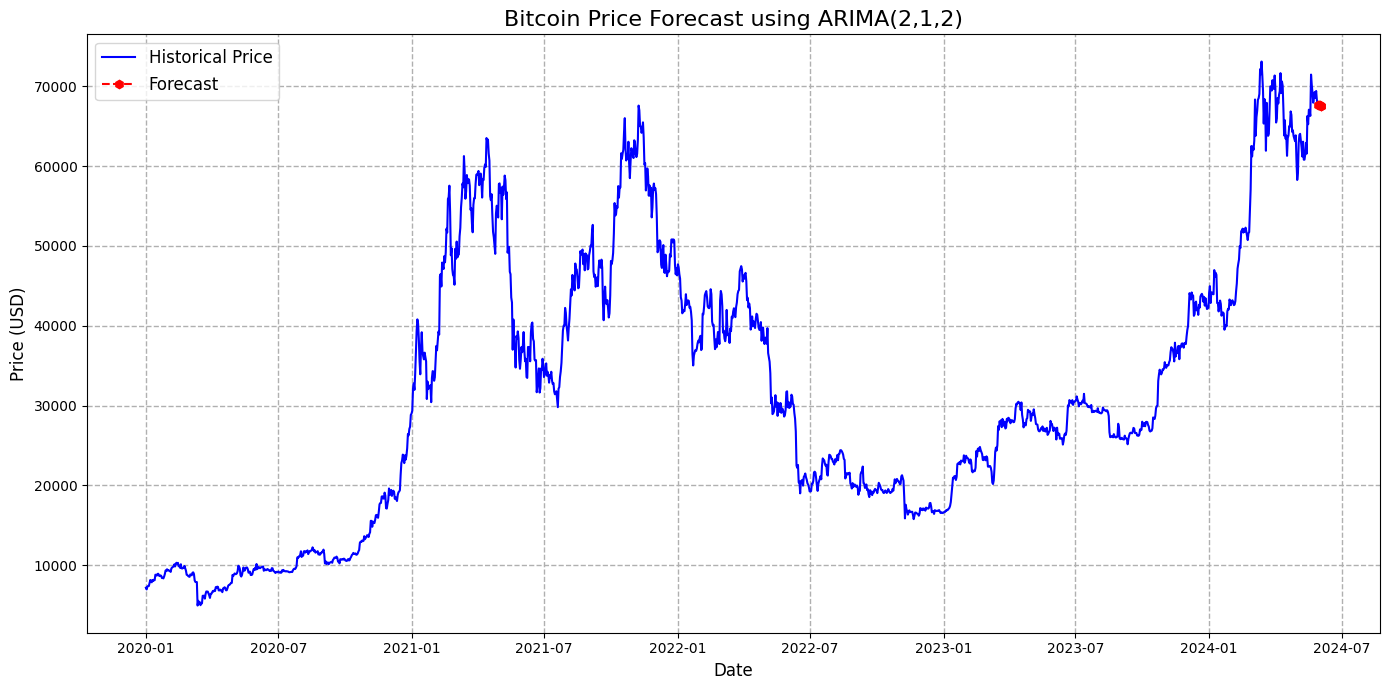

Ticker           BTC-USD
Date                    
2020-01-01   7200.174316
2020-01-02   6985.470215
2020-01-03   7344.884277
2020-01-04   7410.656738
2020-01-05   7411.317383
...                  ...
2024-05-25  69265.945312
2024-05-26  68518.093750
2024-05-27  69394.554688
2024-05-28  68296.218750
2024-05-29  67578.093750

[1611 rows x 1 columns]
ADF Statistic: -0.9285665756416703
p-value: 0.7784195497233866


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [ ]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Download Bitcoin data
btc_data = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")
close_prices = btc_data['Close'].dropna()

# Fit ARIMA(p,d,q) model
model = ARIMA(close_prices, order=(2, 1, 2))  # ARIMA(2,1,2)
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


# plot graph
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(close_prices.index, close_prices, label='Historical Price', color='blue')

# Forecast next 5 days
forecast = model_fit.forecast(steps=5)
print("5-day forecast:", forecast)

# Plot forecasted values
forecast_index = pd.date_range(start=close_prices.index[-1], periods=6, freq='d')[1:]  # Next 5 days
plt.plot(forecast_index, forecast, label='Forecast', color='red', linestyle='--', marker='h')

# Plot confidence intervals (optional)
# conf_int = model_fit.get_forecast(steps=5).conf_int()
# plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

# Formatting the plot
plt.title('Bitcoin Price Forecast using ARIMA(2,1,2)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=1)
plt.tight_layout()

# Show the plot
plt.show()

# Demonstration handling of
# Missing Data
close_prices = btc_data['Close'].dropna()
print(close_prices)

# Non stationarity
model = ARIMA(close_prices, order=(2, 1, 2))  # ARIMA(p=2, d=1, q=2)
print(model)

from statsmodels.tsa.stattools import adfuller
result = adfuller(close_prices)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Temporal Dependencies

model1 = ARIMA(close_prices, order=(2, 1, 2))
print(model1)



** Garch model **

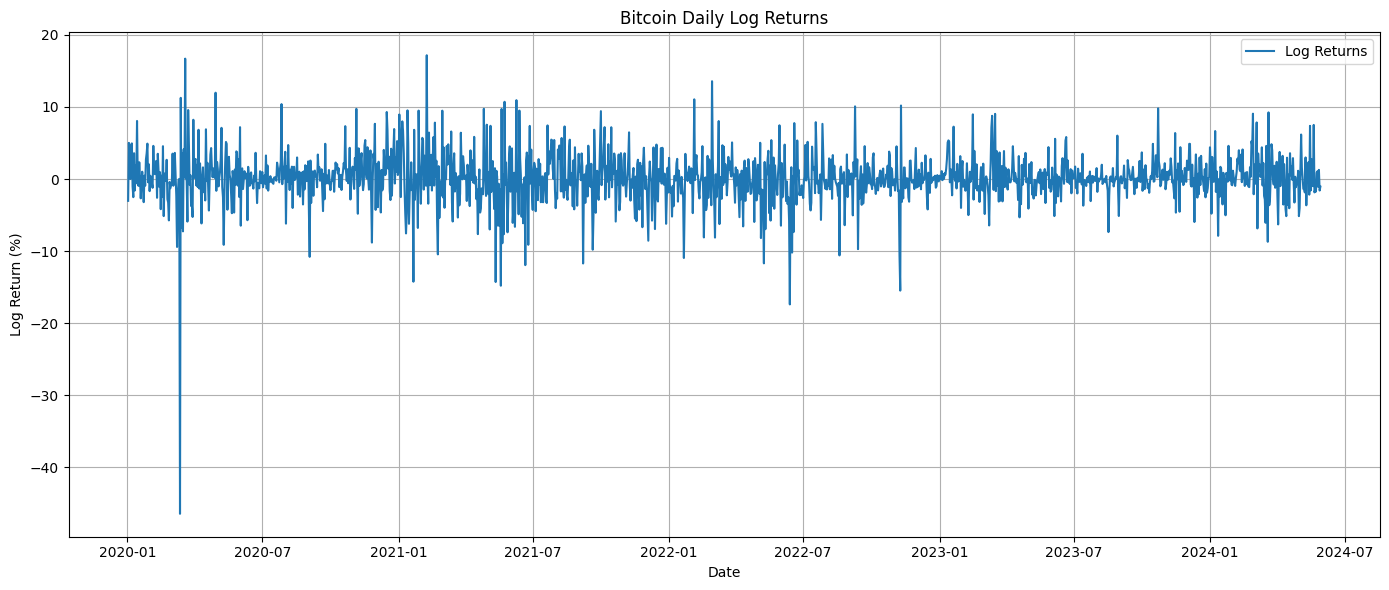

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                BTC-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4223.97
Distribution:                  Normal   AIC:                           8455.94
Method:            Maximum Likelihood   BIC:                           8477.48
                                        No. Observations:                 1610
Date:                Mon, Jun 16 2025   Df Residuals:                     1609
Time:                        07:46:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.2299  9.200e-02      2.499  1.246e-02 [4.958e-0

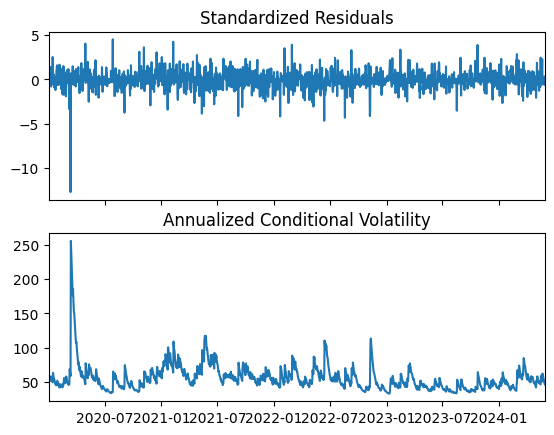

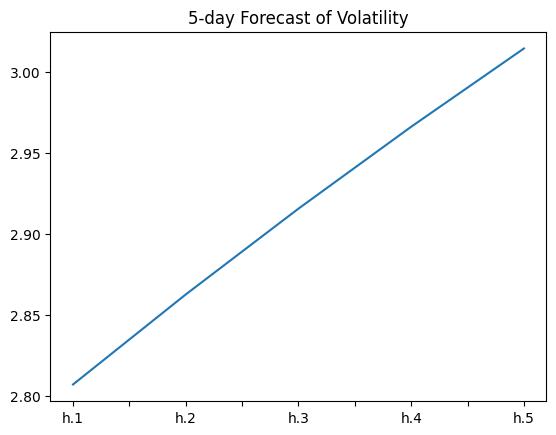


5-day Forecasted Volatility (standard deviation in %):
h.1    2.806894
h.2    2.862447
h.3    2.915405
h.4    2.965950
h.5    3.014245
Name: 2024-05-29 00:00:00, dtype: float64


In [ ]:
!pip install arch
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model


# Compute daily returns (log returns are common)
returns = 100 * np.log(close_prices / close_prices.shift(1)).dropna()

# Plot returns to visualize volatility clustering
plt.figure(figsize=(14, 6))
plt.plot(returns, label="Log Returns")
plt.title("Bitcoin Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Fit GARCH(1,1) model
model = arch_model(returns, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
model_fit = model.fit(disp='off')

# Print model summary
print(model_fit.summary())

# Plot volatility (conditional standard deviation)
fig = model_fit.plot(annualize='D')
plt.show()

# Forecast volatility for next 5 days
forecast = model_fit.forecast(horizon=5)
forecast_variance = forecast.variance.iloc[-1]
forecast_volatility = np.sqrt(forecast_variance)

# plot forecast volatility
fig1 = forecast_volatility.plot(title="5-day Forecast of Volatility")
plt.show()

print("\n5-day Forecasted Volatility (standard deviation in %):")
print(forecast_volatility)


** Forecasting with Prophet**

[*********************100%***********************]  1 of 1 completed


          ds            y
0 2020-01-01  7200.174316
1 2020-01-02  6985.470215
2 2020-01-03  7344.884277
3 2020-01-04  7410.656738
4 2020-01-05  7411.317383
ds    datetime64[ns]
y            float64
dtype: object


DEBUG:cmdstanpy:input tempfile: /tmp/tmp5z2spn6n/1qs986y6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5z2spn6n/1zai3eck.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6052', 'data', 'file=/tmp/tmp5z2spn6n/1qs986y6.json', 'init=/tmp/tmp5z2spn6n/1zai3eck.json', 'output', 'file=/tmp/tmp5z2spn6n/prophet_modelcr4iiucp/prophet_model-20250615135102.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:51:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:51:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


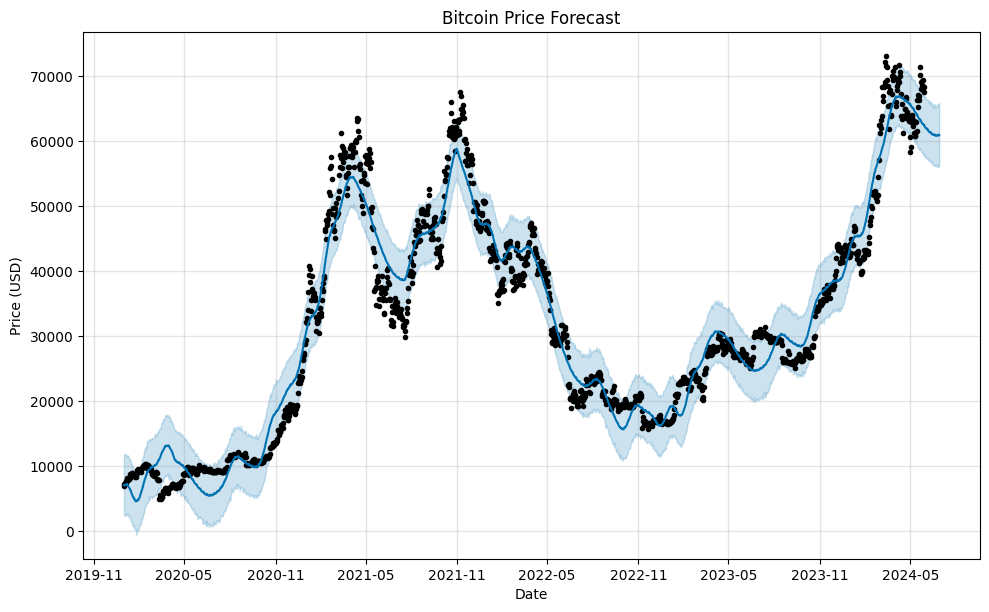

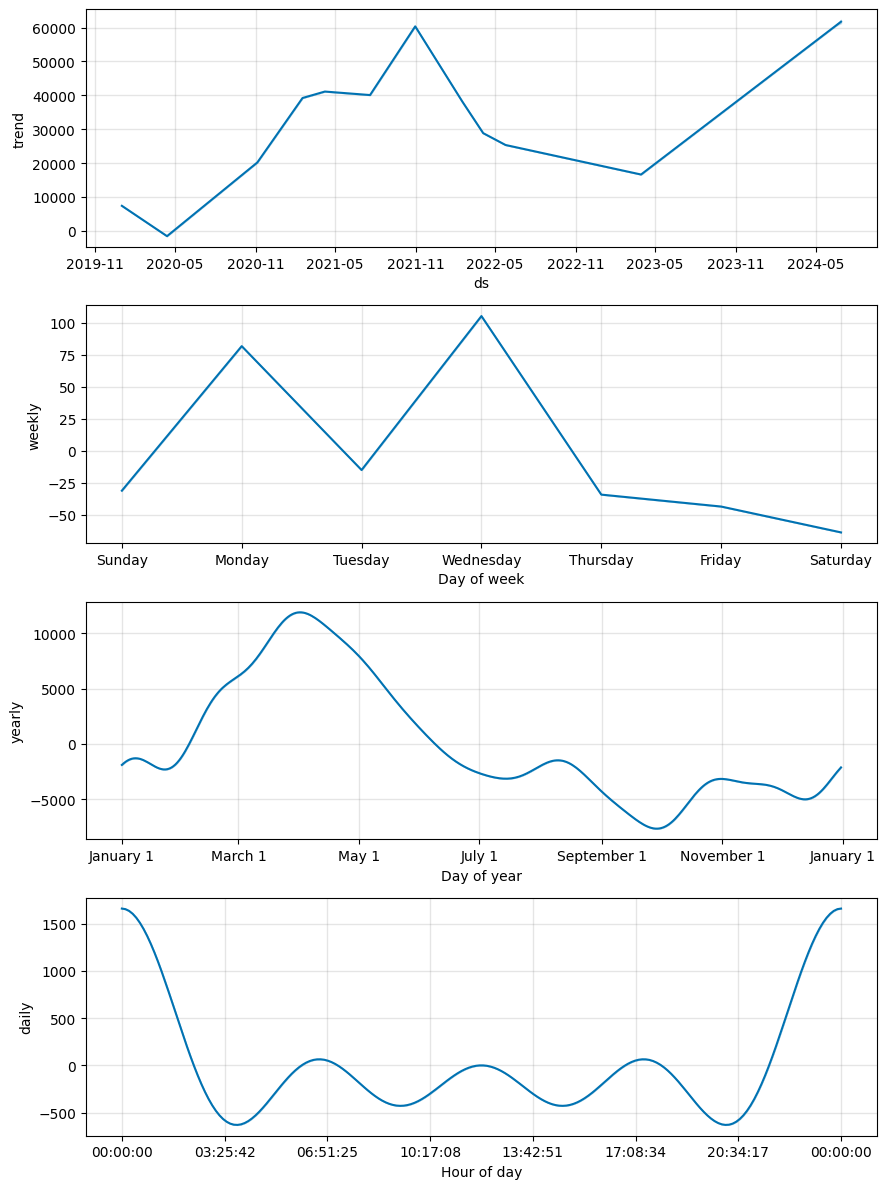

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Step 1: Download Bitcoin data
btc = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")

# Step 2: Prepare the dataframe for Prophet
df = btc.reset_index()[['Date', 'Close']]  # Ensure proper columns
df.columns = ['ds', 'y']                   # Rename columns to Prophet format
df['ds'] = pd.to_datetime(df['ds'])        # Convert to datetime

# Step 3: Drop rows with missing values
df = df.dropna()

# ✅ Check column types and print
print(df.head())
print(df.dtypes)

# Step 4: Ensure 'y' is a valid Series for conversion
if 'y' in df.columns:
    df['y'] = pd.to_numeric(df['y'], errors='coerce')
else:
    raise KeyError("'y' column not found in dataframe!")

df = df.dropna()

# Step 5: Fit and forecast with Prophet
try:
    model = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model.fit(df)

    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)

    model.plot(forecast)
    plt.title("Bitcoin Price Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.show()

    model.plot_components(forecast)
    plt.show()

except Exception as e:
    print(f"An error occurred: {str(e)}")


** LSTM **

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0582
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0024
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0019
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0020
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0018
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0015
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0016
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0013
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0011
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0012
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0011
Epoch 12/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0010
Epoch 13/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0010
Epoch 14/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0012
Epoch 15/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 8.1759e-0

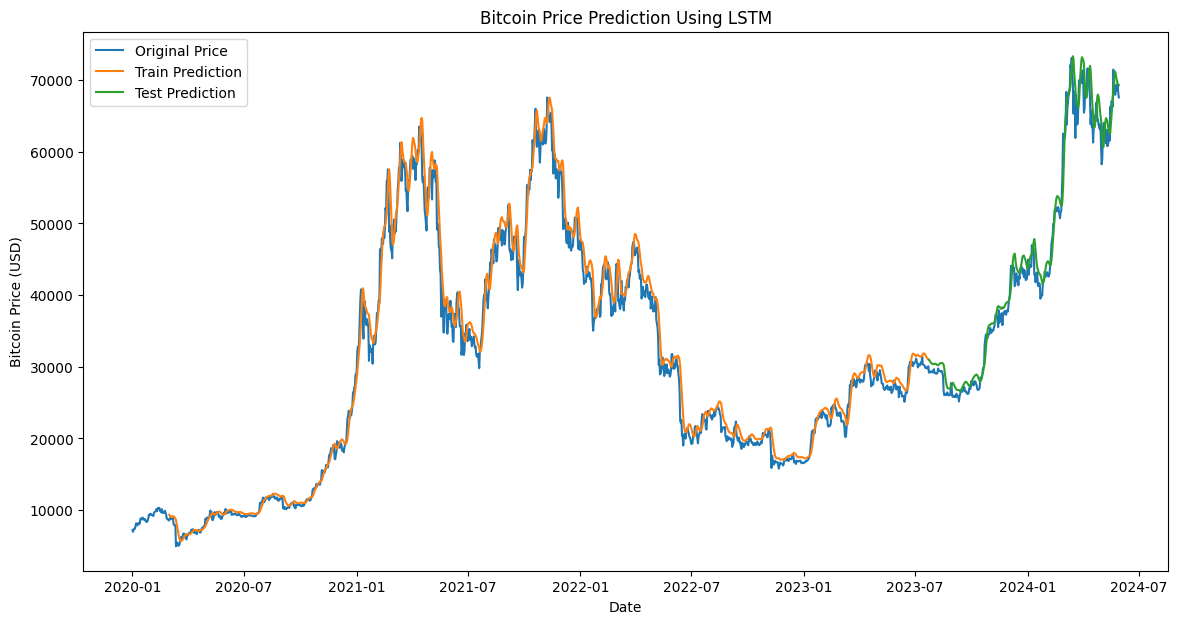

In [ ]:
!pip install tensorflow
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Download Bitcoin data
btc = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")
data = btc['Close'].values.reshape(-1,1)

# Scale data to [0,1]
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Prepare dataset for LSTM: create sequences of length 60 to predict next price
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i,0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Reshape X to be [samples, time_steps, features] which is required for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into train and test (e.g. 80% train)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Predict on test data
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scale predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Plot results
plt.figure(figsize=(14,7))
plt.plot(btc.index, data, label='Original Price')

# Shift train predictions for plotting
train_plot = np.empty_like(data)
train_plot[:] = np.nan
train_plot = np.empty_like(data)  # data is (n,1)
train_plot = train_plot.flatten() # make 1D array
train_plot[:] = np.nan

train_plot[time_step:train_size+time_step] = train_predict.flatten()


# Shift test predictions for plotting
test_plot = np.empty_like(data)
test_plot[:] = np.nan
test_plot[train_size+time_step:] = test_predict.flatten().reshape(-1, 1)
plt.plot(btc.index, train_plot, label='Train Prediction')
plt.plot(btc.index, test_plot, label='Test Prediction')
plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using LSTM')
plt.legend()
plt.show()


hyperparameter tuning process for prophet


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5z2spn6n/wbew4qj0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5z2spn6n/1nsloo88.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93028', 'data', 'file=/tmp/tmp5z2spn6n/wbew4qj0.json', 'init=/tmp/tmp5z2spn6n/1nsloo88.json', 'output', 'file=/tmp/tmp5z2spn6n/prophet_modelvregtogs/prophet_model-20250615135241.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:52:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:52:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
[*********************100%**************

Data sample:
Price          ds            y
Ticker                 BTC-USD
0      2020-01-01  7200.174316
1      2020-01-02  6985.470215
2      2020-01-03  7344.884277
3      2020-01-04  7410.656738
4      2020-01-05  7411.317383

Data types:
Price  Ticker 
ds                datetime64[ns]
y      BTC-USD           float64
dtype: object
An error occurred: arg must be a list, tuple, 1-d array, or Series


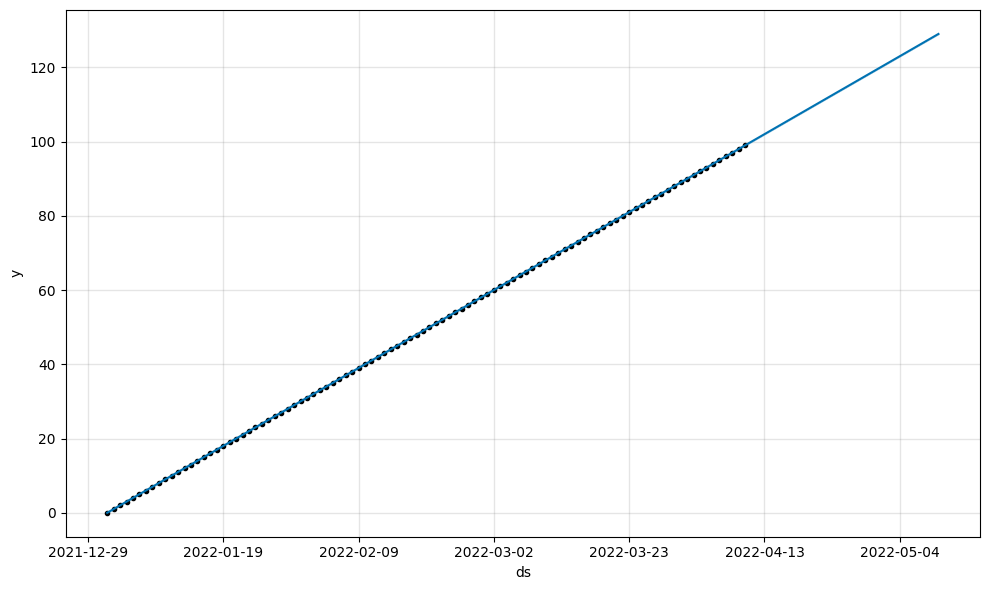

In [ ]:
import yfinance as yf
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'ds': pd.date_range(start='2022-01-01', periods=100),
    'y': range(100)
})

model = Prophet()
model.fit(df)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
model.plot(forecast)


# Step 1: Download Bitcoin data
btc = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")

# Step 2: Prepare the dataframe for Prophet
df = btc.reset_index()[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])

# Step 3: Remove missing values
df = df.dropna()

# Step 4: Display sample data and types
print("Data sample:")
print(df.head())
print("\nData types:")
print(df.dtypes)

# Step 5: Prophet Model with Hyperparameter Tuning
try:
    # Clean the data
    df_clean = df[['ds', 'y']].copy()
    df_clean['ds'] = pd.to_datetime(df_clean['ds'])
    df_clean['y'] = pd.to_numeric(df_clean['y'], errors='coerce')
    df_clean = df_clean.dropna()

    # --- Hyperparameter Tuning Notes ---
    # Prophet has several tunable parameters:
    # 1. seasonality_mode: 'additive' or 'multiplicative' (default: 'additive')
    #    -> 'multiplicative' is better for prices that grow exponentially
    # 2. changepoint_prior_scale: flexibility of trend changepoints (default: 0.05)
    #    -> higher value = more flexible model (less smooth)
    # 3. seasonality_prior_scale: how much seasonal components can fit (default: 10.0)
    # 4. holidays_prior_scale: flexibility of holiday effects (default: 10.0)
    # 5. yearly_seasonality, weekly_seasonality, daily_seasonality: can be True/False or integer Fourier order

    # Example tuned Prophet model
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',          # better for BTC price scaling
        changepoint_prior_scale=0.2,                # more flexible trend
        seasonality_prior_scale=15.0                # more flexible seasonal components
    )

    # Optional: Add custom seasonality if needed
    # model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    # Fit the model
    model.fit(df_clean)

    # Step 6: Forecast for next 30 days
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)

    # Step 7: Plot forecast
    fig1 = model.plot(forecast)
    plt.plot(btc.index, train_plot, label='Train Prediction')
    plt.plot(btc.index, test_plot, label='Test Prediction')
    plt.title("Bitcoin Price Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.show()

    # Step 8: Forecast component plots
    fig2 = model.plot_components(forecast)
    plt.show()

except Exception as e:
    print(f"An error occurred: {str(e)}")


hyperparameter tuning process for LSTM



In [ ]:
!pip install optuna
!pip install tensorflow
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam



# Step 1: Download and preprocess data
data = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")['Close'].dropna()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 30
X, y = create_sequences(scaled_data, SEQ_LENGTH)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 2: Define model builder
def build_model(trial):
    model = Sequential()
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    hidden_units = trial.suggest_int('hidden_units', 32, 128)
    learning_rate = trial.suggest_loguniform('lr', 1e-4, 1e-2)

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        if i == 0:
            model.add(LSTM(hidden_units, return_sequences=return_seq, input_shape=(SEQ_LENGTH, 1)))
        else:
            model.add(LSTM(hidden_units, return_sequences=return_seq))
        model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer=A)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 18.2 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed


Evaluation & Visualization
 Compare models using:

▪ Time-series cross-validation
▪ Economic significance metrics (e.g., hypothetical trading returns)
▪ Statistical error measures (RMSE, MAE)


**To evaluate and compare LSTM models **



*   . Statistical Error Metrics
These show how well the model fits the actual price data:

RMSE (Root Mean Squared Error)

MAE (Mean Absolute Error)



*



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming y_test_actual and test_predict are already available
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
mae = mean_absolute_error(y_test_actual, test_predict)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


RMSE: 1785.82
MAE: 1269.11


**Time-Series Cross-Validation (Rolling Forecast Origin)**

In [ ]:
def rolling_cv(data, time_step, test_size=0.2, n_splits=5):
    step = int((len(data) * (1 - test_size)) / n_splits)
    errors = []

    for i in range(n_splits):
        end_train = time_step + i * step
        X, y = create_dataset(data, time_step)
        X_train, y_train = X[:end_train], y[:end_train]
        X_test, y_test = X[end_train:end_train+step], y[end_train:end_train+step]

        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
        model.add(LSTM(50))
        model.add(Dense(1))
        model.compile(loss='mean_squared_error', optimizer='adam')
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

        preds = model.predict(X_test)
        y_test = y_test.reshape(-1, 1)
        preds_inv = scaler.inverse_transform(preds)
        y_test_inv = scaler.inverse_transform(y_test)

        rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
        errors.append(rmse)

    print(f"Average CV RMSE: {np.mean(errors):.2f}")
    print(f"Standard Deviation of CV RMSE: {np.std(errors):.2f}")


**Economic Significance: Hypothetical Trading Strategy
Simple long/short strategy based on predicted price movement**

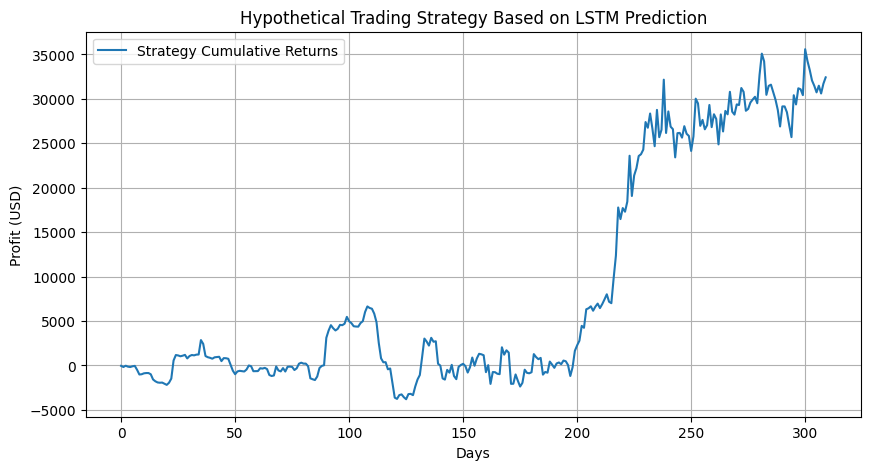

Total Return: 32425.51
Mean Daily Return: 104.5984


In [ ]:
# Use predicted prices (test_predict) and actual prices (y_test_actual)
pred_diff = test_predict[1:] - test_predict[:-1]
actual_diff = y_test_actual[1:] - y_test_actual[:-1]

# Signal: +1 for predicted up, -1 for predicted down
signals = np.sign(pred_diff)
returns = signals * actual_diff  # hypothetical daily return

# Cumulative returns
cum_returns = np.cumsum(returns)

plt.figure(figsize=(10, 5))
plt.plot(cum_returns, label='Strategy Cumulative Returns')
plt.title("Hypothetical Trading Strategy Based on LSTM Prediction")
plt.xlabel("Days")
plt.ylabel("Profit (USD)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Total Return: {cum_returns[-1]:.2f}")
print(f"Mean Daily Return: {np.mean(returns):.4f}")


**interactive visualizations**

[*********************100%***********************]  1 of 1 completed
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5z2spn6n/4yapaem6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5z2spn6n/tvelwdst.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=26397', 'data', 'file=/tmp/tmp5z2spn6n/4yapaem6.json', 'init=/tmp/tmp5z2spn6n/tvelwdst.json', 'output', 'file=/tmp/tmp5z2spn6n/prophet_model34e5u9vb/prophet_model-20250615135250.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:52:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:52:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


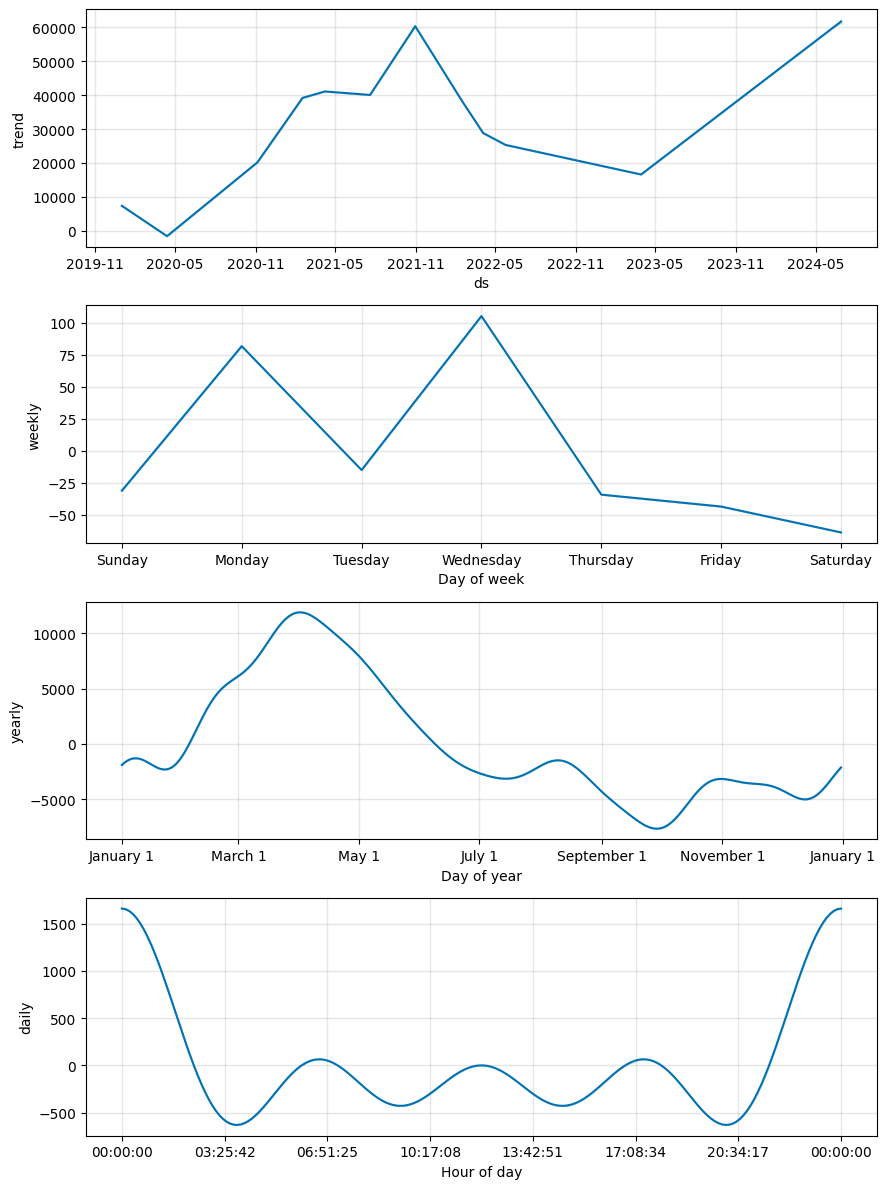

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import plotly.graph_objs as go
import plotly.express as px

# Step 1: Load data
btc = yf.download("BTC-USD", start="2020-01-01", end="2024-05-30")
df = btc.reset_index()[['Date', 'Close']]
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Step 2: Fit Prophet
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df)

# Step 3: Forecast
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Step 4: Merge actual & predicted for interactive plotting
merged = pd.merge(df, forecast[['ds', 'yhat']], on='ds', how='left')

# ------------------------------------------
# ✅ 1. Interactive Plot: Prediction vs Actual
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=merged['ds'], y=merged['y'], mode='lines', name='Actual'))
fig1.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat'], mode='lines', name='Forecast'))
fig1.update_layout(title='Bitcoin: Actual vs Forecast',
                   xaxis_title='Date', yaxis_title='Price (USD)')
fig1.show()

# ------------------------------------------
# ✅ 2. Residual Analysis: Actual - Forecast
merged['residual'] = merged['y'] - merged['yhat']
fig2 = px.line(merged, x='ds', y='residual', title='Residuals Over Time')
fig2.update_layout(xaxis_title='Date', yaxis_title='Residual (Actual - Predicted)')
fig2.show()

# ------------------------------------------
# ✅ 3. Feature Importance (Workaround)

# Prophet doesn’t output feature importance directly, but we can see the trend/seasonality breakdown:
fig3 = model.plot_components(forecast)  # Not interactive, but informative

# For truly interactive feature importance, consider adding custom regressors or switching to XGBoost or LSTM
